In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy as sc
import sympy as sp

In [2]:
dt0 = pd.read_csv('N0.tsv',sep = '\t').loc[:4]
dt0

,l,N,T,j,eps
0,0.0,586549,10.0,58654.9,0.0013
1,0.0,592023,10.0,59202.3,0.0013
2,0.0,580744,10.0,58074.4,0.0013
3,0.0,288045,5.0,57609.0,0.0019
4,0.0,286718,5.0,57343.6,0.0019


N_i
N-Ni
N0-Ni

I=I0*e^(-mu*l), I~N
N=N0*e^(-mu*l)
N_n=N_1*e^(mu*(l_1-l_n))

In [3]:
dta = pd.read_csv('plub.tsv',sep = '\t') 
dta

,l,N,T,j,eps
0,4.9,154223,5.0,30844.60,0.0025
1,4.9,154349,5.0,30869.80,0.0025
2,4.9,153851,5.0,30770.20,0.0025
3,9.4,87959,5.0,17591.80,0.0034
4,9.4,87908,5.0,17581.60,0.0034
5,9.4,175487,10.0,17548.70,0.0024
6,9.4,176045,10.0,17604.50,0.0024
7,9.4,176275,10.0,17627.50,0.0024
8,14.1,101158,10.0,10115.80,0.0031
9,14.1,100264,10.0,10026.40,0.0032


In [4]:
139525/40

3488.125

In [14]:
def recalc(gr):
    #j_new = (gr.j/(gr.eps*gr.j)**2).sum()/(1/(gr.eps*gr.j)**2).sum()
    #eps_new = 1/np.sqrt((1/(gr.eps*gr.j)**2).sum())/j_new
    j=gr["N"]/gr["T"]
    e=j/np.sqrt(gr["N"])
    j_new = np.average(j)
    #print(np.std(j), 1/np.sqrt((1/e**2)).sum())
    eps_new = np.sqrt(np.std(j)**2+1/(1/e**2).sum())/j_new
    return pd.Series({'j': j_new, 'eps': eps_new})

In [15]:
dt0r=dt0.groupby(["l"]).apply(recalc).reset_index()

In [16]:
dt0r

,l,j,eps
0,0.0,58176.84,0.011695


In [17]:
np.log(dt0r.j)

0    10.971243
Name: j, dtype: float64

In [18]:
#from numpy.polynomial import Polynomial
#model = Polynomial.fit(dtar.l,np.log(dtar.j), deg=1)

# Коэффициенты b и k для уравнения y = kx + b
#b, k = model.convert().coef
#model.convert()

In [19]:
#res = sc.stats.linregress(dtar.l,np.log(dtar.j))
#res

In [20]:
#plt.errorbar(dtar.l,np.log(dtar.j), yerr=dtar.eps*3, fmt='none', color='red', linestyle='none')
#plt.plot(dtar.l, dtar.l*k+b, '--')
#plt.plot(dta.l, np.log(dta.j), 'x')

In [21]:

for fl in ['alum', 'plub', 'steel']:
    break
    dta = pd.read_csv(fl+'.tsv',sep = '\t') 
    dtar=dta.groupby(["l"]).apply(recalc).reset_index()
    model = Polynomial.fit(dtar.l,np.log(dtar.j), deg=1)
    b, k = model.convert().coef
    print(b,k*10)
    fig, ax = plt.subplots()
    ax.errorbar(dtar.l,np.log(dtar.j), yerr=dtar.eps*3, fmt='none', color='red', linestyle='none')
    ax.plot(dtar.l, dtar.l*k+b, '--')
    ax.plot(dta.l, np.log(dta.j), 'x')

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


10.971242616376804
10.973832679735374 0.006428950005865521 -0.19826359863070575 -0.00416314940791981
0.006176735372052454 0.00717193372777086
10.881357611053804 0.01868628723777114 -1.1651673578877537 -0.008726869144164887
0.01787286409776641 0.020770473012093414
10.902806798822457 0.018148035665929364 -0.5481749098555792 -0.008500909627997667
0.017436068678244467 0.020245375833816547


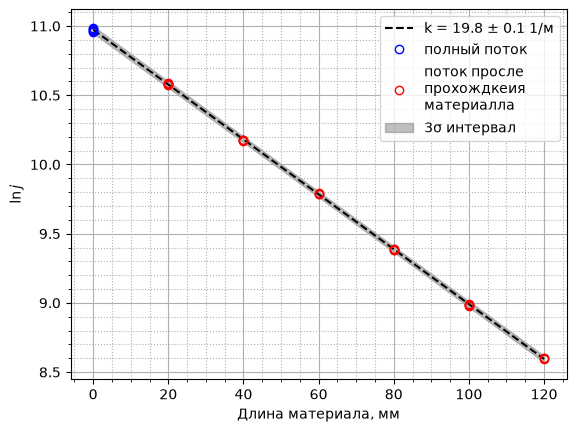

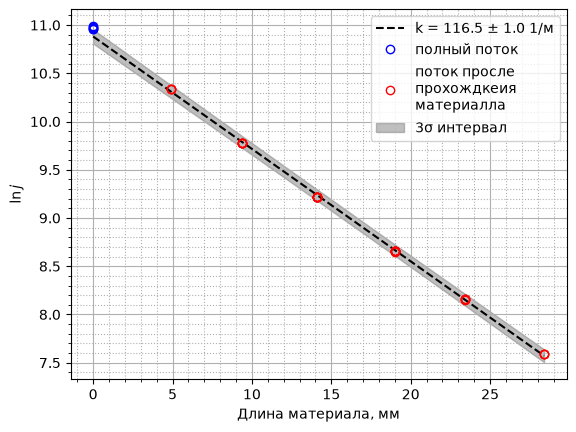

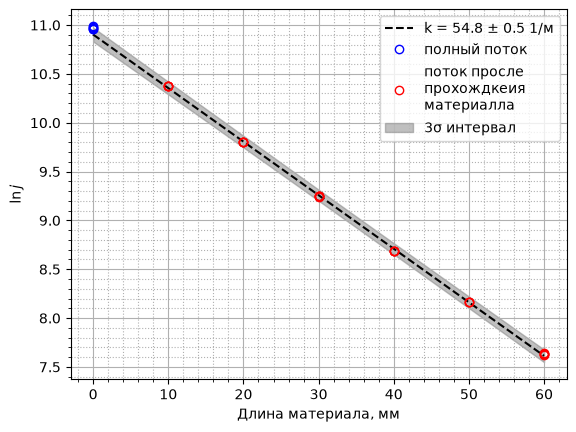

In [33]:
print(np.log(dt0r.j).loc[0])
for fl in ['alum', 'plub', 'steel']:
    dta = pd.read_csv(fl + '.tsv', sep='\t')
    #dta = pd.concat([dt0, dta], ignore_index=True)
    dtar = dta.groupby(["l"]).apply(recalc).reset_index()
    
    x = dtar.l.to_numpy()
    y = np.log(dtar.j.to_numpy())

    res = sc.stats.linregress(x, y)
    b, k = res.intercept, res.slope
    print(b, res.intercept_stderr, k * 10, res.stderr/k)

    # 3σ полоса вокруг линии регрессии
    n = x.size
    xf = np.linspace(0, x.max(), 200)
    yf = b + k * xf
    s = np.sqrt(np.sum((y - (b + k * x))**2) / (n - 1))
    sxx = np.sum((x - x.mean())**2)
    se_pred = s * np.sqrt(1 + 1/n + (xf - x.mean())**2 / sxx)

    print(s,np.average(se_pred))
    
    fig, ax = plt.subplots()
    #ax.errorbar(dta.l, np.log(dta.j), yerr=dta.eps*3, fmt=',')
    if (fl!="plub"):
        ax.plot(xf, yf, '--', label=f'k = {-k*1000:.1f} ± {res.stderr*1000:.1f} 1/м', color="black")
    else:
        ax.plot(xf, yf, '--', label=f'k = {-k*1000:.1f} ± {res.stderr*1000:.1f} 1/м', color="black")
    
    #ax.errorbar(x, y, yerr=dtar.eps * 3, xerr=0.25, fmt='none', color='red')
    ax.plot(dt0.l, np.log(dt0.j), 'o',fillstyle='none', color='blue', label = "полный поток")
    ax.plot(dta.l, np.log(dta.j), 'o',fillstyle='none', color='red', label = "поток просле\nпрохождкеия\nматериалла")
    ax.fill_between(xf, yf - 3*se_pred, yf + 3*se_pred,
                    color='gray', alpha=0.5, label='3σ интервал')
    ax.set_ylabel(r"$\ln{j}$")
    ax.set_xlabel(r"Длина материала, мм")
    ax.minorticks_on()
    ax.grid(which='major')
    ax.grid(which='minor', linestyle=':')
    
    ax.legend()
    fig.savefig(fl+".eps")